## 5.6 규제 선형 모델 -릿지, 라쏘, 엘라스틱넷

### 규제 선형 모델의 개요
- 최적 모델을 위한 cost함수= 학습데이터 잔차 오류 최소화 + 회귀계수 크기 제어
- 비용 함수 목표: min(RSS(W) + alpha * ||W||^2_2) 
  >alpha: 학습 데이터 적합 정도와 회귀 계수 값의 크기 제어를 수행하는 튜닝 파라미터
  >alpha값이 크면 과적합 개선, 작으면 학습 데이터 적합 개선 가능
- 규제(regularization): 비용 함수에 alpha값으로 페널티를 부여해 회귀 계수 값의 크기를 감소시켜 과적합을 개선하는 방식
  >L2: W의 제곱에 대해 페널티를 부여하는 방식/ L1: W의 절댓값에 대해 페널티를 부여하는 방식
  >릿지 회귀는 L2규제 적용, 라쏘 회귀는 L1규제 적용

### 릿지(Ridge) 회귀
 > 회귀 계수의 크기를 감소시킴

In [149]:
import pandas as pd
import numpy as np

#앞의 LinearRegression예제에서 분할한 feature 데이터 셋인 X_data과 Target 데이터 셋인 Y_target 데이터셋을 그대로 이용 
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

#boston 데이타셋 로드
bostonDF = pd.read_csv('/Users/na-eunseong/Desktop/cuai_bt/Boston.csv')


y_target = bostonDF['medv']
X_data = bostonDF.drop(['medv'],axis=1,inplace=False)


ridge = Ridge(alpha = 10)
neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring="neg_mean_squared_error", cv = 5)
rmse_scores  = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)
print(' 5 folds 의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 3))
print(' 5 folds 의 개별 RMSE scores : ', np.round(rmse_scores,3))
print(' 5 folds 의 평균 RMSE : {0:.3f} '.format(avg_rmse))

#앞 예제의 규제가 없는 LinearRegression의 RMSE 평균보다 더 뛰어난 예측 성능을 보여줌

 5 folds 의 개별 Negative MSE scores:  [-14.604 -24.249 -28.83  -74.663 -27.7  ]
 5 folds 의 개별 RMSE scores :  [3.821 4.924 5.369 8.641 5.263]
 5 folds 의 평균 RMSE : 5.604 


- 릿지의 alpha값을 0, 0.1, 1, 10, 100으로 변화싴키며 RMSE값과 각 피처의 회귀 계수 시각화, DF 저장

In [150]:
#릿지에 사용될 alpha 파라미터의 값을 정의
alphas = [0, 0.1, 1, 10, 100]

#alphas list 값을 반복하면서 alpha에 따른 평균 rmse를 구함.
for alpha in alphas :
    ridge = Ridge(alpha = alpha)
    
    #cross_val_score를 이용해 5 폴드의 평균 RMSE를 계산
    neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring="neg_mean_squared_error", cv = 5)
    avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
    print('alpha {0} 일 때 5 folds 의 평균 RMSE : {1:.3f} '.format(alpha, avg_rmse))

#alpha가 100일 때 평균 RMSE가 가장 좋음을 알 수 있음.

alpha 0 일 때 5 folds 의 평균 RMSE : 5.844 
alpha 0.1 일 때 5 folds 의 평균 RMSE : 5.807 
alpha 1 일 때 5 folds 의 평균 RMSE : 5.693 
alpha 10 일 때 5 folds 의 평균 RMSE : 5.604 
alpha 100 일 때 5 folds 의 평균 RMSE : 5.500 


- 각 alpha에 따른 회귀 계수 값을 시각화. 각 alpha값 별로 plt.subplots로 맷플롯립 축 생성

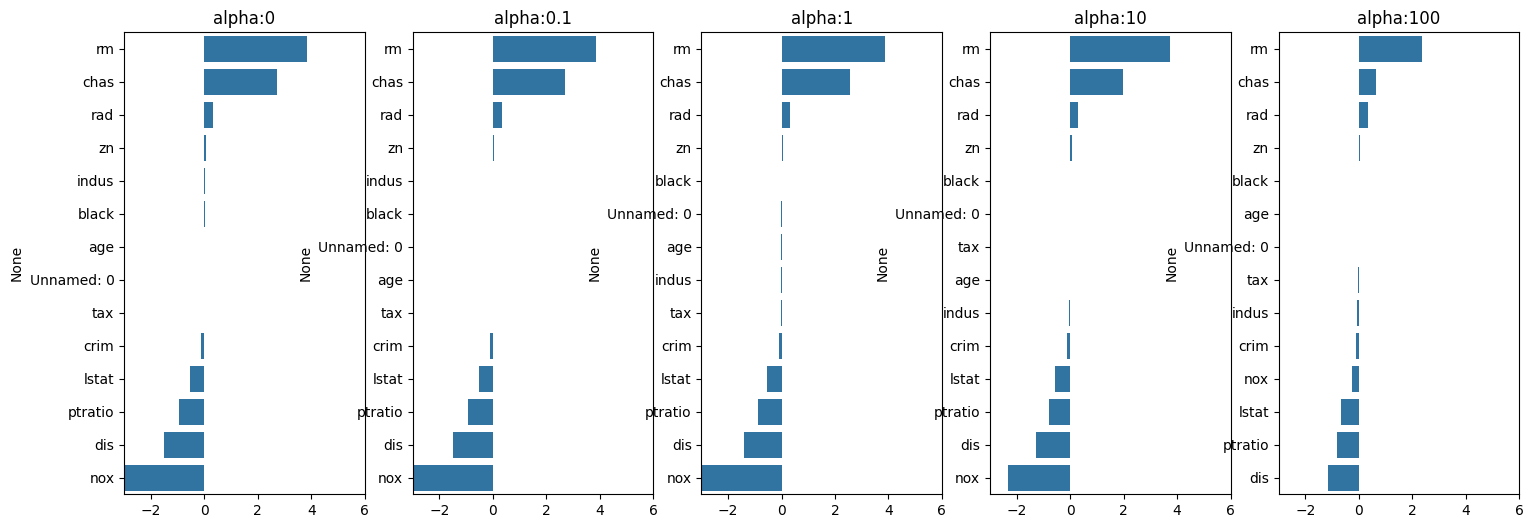

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

#각 alpha에 따른 회귀 계수 값을 시각화하기 위해 5개의 열로 된 맷플롯립 축 생성  
fig , axs = plt.subplots(figsize=(18,6) , nrows=1 , ncols=5)
#각 alpha에 따른 회귀 계수 값을 데이터로 저장하기 위한 DataFrame 생성  
coeff_df = pd.DataFrame()

#alphas 리스트 값을 차례로 입력해 회귀 계수 값 시각화 및 데이터 저장. pos는 axis의 위치 지정
for pos , alpha in enumerate(alphas) :
    ridge = Ridge(alpha = alpha)
    ridge.fit(X_data , y_target)
    # alpha에 따른 피처별 회귀 계수를 Series로 변환하고 이를 DataFrame의 컬럼으로 추가.  
    coeff = pd.Series(data=ridge.coef_ , index=X_data.columns )
    colname='alpha:'+str(alpha)
    coeff_df[colname] = coeff
    # 막대 그래프로 각 alpha 값에서의 회귀 계수를 시각화. 회귀 계수값이 높은 순으로 표현
    coeff = coeff.sort_values(ascending=False)
    axs[pos].set_title(colname)
    axs[pos].set_xlim(-3,6)
    sns.barplot(x=coeff.values , y=coeff.index, ax=axs[pos])

#for문 바깥에서 맷플롯립의 show 호출 및 alpha에 따른 피처별 회귀 계수를 DataFrame으로 표시
plt.show()

#alpha 값을 증가시킬수록 회귀 계수 값이 지속적으로 작아짐

- DataFrame에 저장된 alpha 값의 변화에 따른 릿지 회귀 계수 값 출력

In [152]:
ridge_alphas = [0 , 0.1 , 1 , 10 , 100]
sort_column = 'alpha:'+str(ridge_alphas[0])
coeff_df.sort_values(by=sort_column, ascending=False)

,alpha:0,alpha:0.1,alpha:1,alpha:10,alpha:100
rm,3.839225,3.847742,3.884133,3.730589,2.348374
chas,2.705245,2.688771,2.572215,1.968828,0.642700
rad,0.324925,0.322626,0.310511,0.301086,0.332157
zn,0.048031,0.048197,0.049148,0.051333,0.055823
indus,0.019932,0.015425,-0.009068,-0.042707,-0.052455
black,0.009357,0.009413,0.009716,0.010075,0.009416
age,-0.001938,-0.002915,-0.008131,-0.013394,-0.000734
Unnamed: 0,-0.002526,-0.002553,-0.002694,-0.002796,-0.002172
tax,-0.011598,-0.011675,-0.012119,-0.013164,-0.015208
crim,-0.108762,-0.108240,-0.105445,-0.102379,-0.102900


### 라쏘(Lasso) 회귀
 > 불필요한 회귀 계수를 급격하게 감소시켜 0으로 만들고 제거, 적절한 피처만 회귀에 포함

In [153]:
from sklearn.linear_model import Lasso, ElasticNet

#alpha값에 따른 회귀 모델의 폴드 평균 RMSE를 출력하고 회귀 계수값들을 DataFrame으로 반환 
def get_linear_reg_eval(model_name, params=None, X_data_n=None, y_target_n=None, 
                        verbose=True, return_coeff=True):
    coeff_df = pd.DataFrame()
    if verbose : print('####### ', model_name , '#######')
    for param in params:
        if model_name =='Ridge': model = Ridge(alpha=param)
        elif model_name =='Lasso': model = Lasso(alpha=param)
        elif model_name =='ElasticNet': model = ElasticNet(alpha=param, l1_ratio=0.7)
        neg_mse_scores = cross_val_score(model, X_data_n, 
                                             y_target_n, scoring="neg_mean_squared_error", cv = 5)
        avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
        print('alpha {0}일 때 5 폴드 세트의 평균 RMSE: {1:.3f} '.format(param, avg_rmse))
        #cross_val_score는 evaluation metric만 반환하므로 모델을 다시 학습하여 회귀 계수 추출
        
        model.fit(X_data_n , y_target_n)
        if return_coeff:
            #alpha에 따른 피처별 회귀 계수를 Series로 변환하고 이를 DataFrame의 컬럼으로 추가. 
            coeff = pd.Series(data=model.coef_ , index=X_data_n.columns )
            colname='alpha:'+str(param)
            coeff_df[colname] = coeff
    
    return coeff_df
#end of get_linear_regre_eval

In [154]:
#라쏘에 사용될 alpha 파라미터의 값들을 정의하고 get_linear_reg_eval() 함수 호출
lasso_alphas = [ 0.07, 0.1, 0.5, 1, 3]
coeff_lasso_df =get_linear_reg_eval('Lasso', params=lasso_alphas, X_data_n=X_data, y_target_n=y_target)

#alpha가 0.07일 때 가장 좋은 평균RMSE를 보여줌

#######  Lasso #######
alpha 0.07일 때 5 폴드 세트의 평균 RMSE: 5.714 
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.731 
alpha 0.5일 때 5 폴드 세트의 평균 RMSE: 5.868 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 6.082 
alpha 3일 때 5 폴드 세트의 평균 RMSE: 6.783 


- alpha값에 따른 피처별 회귀 계수

In [155]:
#반환된 coeff_lasso_df를 첫번째 컬럼순으로 내림차순 정렬하여 회귀계수 DataFrame출력
sort_column = 'alpha:'+str(lasso_alphas[0])
coeff_lasso_df.sort_values(by=sort_column, ascending=False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
rm,3.818942,3.731253,2.514752,0.951835,0.000000
chas,1.456124,0.976090,0.000000,0.000000,0.000000
rad,0.292072,0.295033,0.289568,0.266066,0.043498
zn,0.050777,0.050862,0.050519,0.049306,0.036391
black,0.010285,0.010284,0.009491,0.008250,0.006497
nox,0.000000,0.000000,0.000000,0.000000,0.000000
Unnamed: 0,-0.002738,-0.002631,-0.001545,-0.000216,0.002388
tax,-0.013477,-0.013789,-0.014993,-0.015155,-0.009370
age,-0.014332,-0.012560,0.002135,0.020707,0.043925
indus,-0.041745,-0.036255,-0.004927,-0.000000,0.000000


### 엘라스틱넷(Elastic Net) 회귀
 > L2규제와 L1규제를 결합한 회귀

In [156]:
#엘라스틱넷에 사용될 alpha 파라미터의 값들을 정의하고 get_linear_reg_eval() 함수 호출
#l1_ratio는 0.7로 고정
elastic_alphas = [ 0.07, 0.1, 0.5, 1, 3]
coeff_elastic_df =get_linear_reg_eval('ElasticNet', params=elastic_alphas,
                                      X_data_n=X_data, y_target_n=y_target)

#######  ElasticNet #######
alpha 0.07일 때 5 폴드 세트의 평균 RMSE: 5.647 
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.645 
alpha 0.5일 때 5 폴드 세트의 평균 RMSE: 5.682 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.902 
alpha 3일 때 5 폴드 세트의 평균 RMSE: 6.607 


In [157]:
#반환된 coeff_elastic_df를 첫번째 컬럼순으로 내림차순 정렬하여 회귀계수 DataFrame출력
sort_column = 'alpha:'+str(elastic_alphas[0])
coeff_elastic_df.sort_values(by=sort_column, ascending=False)

#alpha 0.5일 때 RMSE가 가장 좋은 예측 성능을 보임.

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
rm,3.601129,3.438970,1.928772,0.941199,0.000000
chas,1.346550,0.993541,0.000000,0.000000,0.000000
rad,0.299580,0.303398,0.312441,0.293131,0.133409
zn,0.051794,0.052230,0.053800,0.052423,0.037272
black,0.010158,0.010100,0.009132,0.008325,0.007012
Unnamed: 0,-0.002684,-0.002573,-0.001486,-0.000479,0.001819
age,-0.012691,-0.010708,0.006419,0.019934,0.044864
tax,-0.013729,-0.014053,-0.015613,-0.016078,-0.012004
indus,-0.044587,-0.042322,-0.022934,-0.000000,-0.000000
crim,-0.100386,-0.100111,-0.089590,-0.073759,-0.018629


### 선형 회귀 모델을 위한 데이터 변환
- 사이킷럿을 이용해 피처 데이터 세트에 적용하는 변환 작업
  - StandardScaler 클래스를 이용해 평균이 0, 분산이 1인 표준 정규 분포를 가진 데이터 세트로 변환/
    MinMaxScaler 클래스를 이용해 최솟값이 0이고 최댓값이 1인 값으로 정규화 수행
  - 스케일링/정규화를 수행한 데이터 세트에 다시 다항 특성을 적용하여 변환(1번에서 예측 성능 향상이 없을 경우 적용)
  - **로그 변환**: 로그함수를 적용하면 보다 정규분포에 가까운 형태로 값이 분포

In [158]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures

# method는 표준 정규 분포 변환(Standard), 최대값/최소값 정규화(MinMax), 로그변환(Log) 결정
# p_degree는 다향식 특성을 추가할 때 적용. p_degree는 2이상 부여하지 않음. 
def get_scaled_data(method='None', p_degree=None, input_data=None):
    if method == 'Standard':
        scaled_data = StandardScaler().fit_transform(input_data)
    elif method == 'MinMax':
        scaled_data = MinMaxScaler().fit_transform(input_data)
    elif method == 'Log':
        scaled_data = np.log1p(input_data)
    else:
        scaled_data = input_data

    if p_degree != None:
        scaled_data = PolynomialFeatures(degree=p_degree, 
                                         include_bias=False).fit_transform(scaled_data)
    
    return scaled_data

In [159]:
#Ridge의 alpha값을 다르게 적용하고 다양한 데이터 변환방법에 따른 RMSE 추출. 
alphas = [0.1, 1, 10, 100]
#변환 방법은 모두 6개, 원본 그대로, 표준정규분포, 표준정규분포+다항식 특성
#최대/최소 정규화, 최대/최소 정규화+다항식 특성, 로그변환 
scale_methods=[(None, None), ('Standard', None), ('Standard', 2), 
               ('MinMax', None), ('MinMax', 2), ('Log', None)]
for scale_method in scale_methods:
    X_data_scaled = get_scaled_data(method=scale_method[0], p_degree=scale_method[1], 
                                    input_data=X_data)
    print(X_data_scaled.shape, X_data.shape)
    print('\n## 변환 유형:{0}, Polynomial Degree:{1}'.format(scale_method[0], scale_method[1]))
    get_linear_reg_eval('Ridge', params=alphas, X_data_n=X_data_scaled, 
                        y_target_n=y_target, verbose=False, return_coeff=False)

(506, 14) (506, 14)

## 변환 유형:None, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.807 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.693 
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.604 
alpha 100일 때 5 폴드 세트의 평균 RMSE: 5.500 
(506, 14) (506, 14)

## 변환 유형:Standard, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.841 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.821 
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.681 
alpha 100일 때 5 폴드 세트의 평균 RMSE: 5.538 
(506, 119) (506, 14)

## 변환 유형:Standard, Polynomial Degree:2
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 9.700 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 7.583 
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.991 
alpha 100일 때 5 폴드 세트의 평균 RMSE: 4.817 
(506, 14) (506, 14)

## 변환 유형:MinMax, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.787 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.547 
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.933 
alpha 100일 때 5 폴드 세트의 평균 RMSE: 7.720 
(506, 119) (506, 14)

## 변환 유형:MinMax, Polynomial Degree:2
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 6.187 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 4.567 
alpha 10일 때 5 폴드 세트의 평균 RMS

- 선형회귀를 적용하려는 데이터 세트에 데이터 값의 분포가 심하게 왜곡되어 있을 경우 >로그변환 적용

## 5.7 로지스틱 회귀
- 선형 회귀 방식을 분류에 적용한 알고리즘 >분류에 사용
- 시그모이드 함수 최적선을 찾고 이 시그모이드 함수의 반환 값을 확률로 간주해 확률에 따라 분류 결정

- LogisticRegression클래스의 solver파라미터
  - lbfgs: 메모리 공간 절약 가능, CPU코어 수가 많다면 최적화 병렬 수행
  - liblinear: 다차원이고 작은 데이터셋에서 효과적으로 동작, 국소 최적화에 이슈, 병렬 최적화 불가
  - newton-cg: 좀 더 정교한 최적화 가능, 대용량의 데이터에서 속도가 많이 느려짐
  - sag: Stochastic Average Gradient, 경사 하강법 기반의 최적화 적용, 대용량 데이터에서 빠르게 최적화
  - saga: sag와 윻사한 최적화 방식, L1 정규화 가능 *sag는 L2 정규화만 가능

In [160]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()

In [161]:
#데이터에 정규 분포 형태의 표준 스케일링 적용 후 데이터셋 분리
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# StandardScaler( )로 평균이 0, 분산 1로 데이터 분포도 변환
scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)

X_train , X_test, y_train , y_test = train_test_split(data_scaled, cancer.target, test_size=0.3, random_state=0)


In [162]:
from sklearn.metrics import accuracy_score, roc_auc_score

#로지스틱 회귀를 이용하여 학습 및 예측 수행. 
#solver인자값을 생성자로 입력하지 않으면 solver='lbfgs'  
lr_clf = LogisticRegression() # solver='lbfgs'
lr_clf.fit(X_train, y_train)
lr_preds = lr_clf.predict(X_test)
lr_preds_proba = lr_clf.predict_proba(X_test)[:, 1]

#accuracy와 roc_auc 측정
print('accuracy: {0:.3f}, roc_auc:{1:.3f}'.format(accuracy_score(y_test, lr_preds),
                                                 roc_auc_score(y_test , lr_preds_proba)))


accuracy: 0.977, roc_auc:0.995


In [163]:
solvers = ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']
# 여러개의 solver값 별로 LogisticRegression 학습 후 성능 평가
for solver in solvers:
    lr_clf = LogisticRegression(solver=solver, max_iter=600)
    lr_clf.fit(X_train, y_train)
    lr_preds = lr_clf.predict(X_test)
    lr_preds_proba = lr_clf.predict_proba(X_test)[:, 1]

    # accuracy와 roc_auc 측정
    print('solver:{0}, accuracy: {1:.3f}, roc_auc:{2:.3f}'.format(solver, 
                                                                  accuracy_score(y_test, lr_preds),
                                                                  roc_auc_score(y_test , lr_preds_proba)))

solver:lbfgs, accuracy: 0.977, roc_auc:0.995
solver:liblinear, accuracy: 0.982, roc_auc:0.995
solver:newton-cg, accuracy: 0.977, roc_auc:0.995
solver:sag, accuracy: 0.982, roc_auc:0.995
solver:saga, accuracy: 0.982, roc_auc:0.995


- penalty: 규제의 유형을 설정, '12'로 설정 시 L2 규제, '11'로 설정 시 L1 규제
- C: 규제 강도를 조절하는 alpha 값의 역수, C=1/alpha, C값이 작을수록 규제 강도가 큼

- GridSearchCV를 이용해 위스콘신 데이터셋에서 solver, penalty, C를 최적화

In [164]:
from sklearn.model_selection import GridSearchCV

params={'solver':['liblinear', 'lbfgs'],
        'penalty':['l2', 'l1'],
        'C':[0.01, 0.1, 1, 5, 10]}

lr_clf = LogisticRegression()

grid_clf = GridSearchCV(lr_clf, param_grid=params, scoring='accuracy', cv=3 )
grid_clf.fit(data_scaled, cancer.target)
print('최적 하이퍼 파라미터:{0}, 최적 평균 정확도:{1:.3f}'.format(grid_clf.best_params_, 
                                                  grid_clf.best_score_))

최적 하이퍼 파라미터:{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}, 최적 평균 정확도:0.979


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

- solver가 liblinear, Penalty가 L2규제, C값은 0.1일 때 가장 좋은 성능